# ⚙️ Feature Scaling & Standardization — Social Network Ads

**Dataset:** Social Network Ads (`Social_Network_Ads.csv`)  
**Goal:** Apply StandardScaler to normalize features before model training

### What this notebook covers:
- Loading and preparing the dataset
- Train/test split
- Applying StandardScaler on training data
- Transforming test data using the same scaler
- Visualizing before vs after scaling distributions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('Social_Network_Ads.csv')
df=df.iloc[:,2:]

X=df.drop('Purchased',axis=1)
Y=df['Purchased']

X.shape,Y.shape

## ✂️ Train/Test Split
Splitting data 70/30 — training the scaler only on train set to avoid data leakage.

In [46]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,
                                                test_size=0.3,
                                               random_state=0)

X_train.shape,X_test.shape

((280, 2), (120, 2))

## ⚙️ Applying StandardScaler
Fitting scaler on X_train only, then transforming both train and test sets.

In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
# fit the standard scaler to the X_train dataset
scaler.fit(X_train)
# now transform train and test sets
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [16]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [20]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [21]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [22]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [25]:
np.round(X_test_scaled.describe(),1)

,Age,EstimatedSalary
count,120.0,120.0
mean,-0.1,-0.0
std,1.1,1.0
min,-1.9,-1.6
25%,-1.0,-0.7
50%,-0.2,-0.2
75%,0.7,0.5
max,2.2,2.3


## 📊 Visualizing Before vs After Scaling
Comparing original and scaled feature distributions.

Text(0.5, 1.0, 'After scaling')

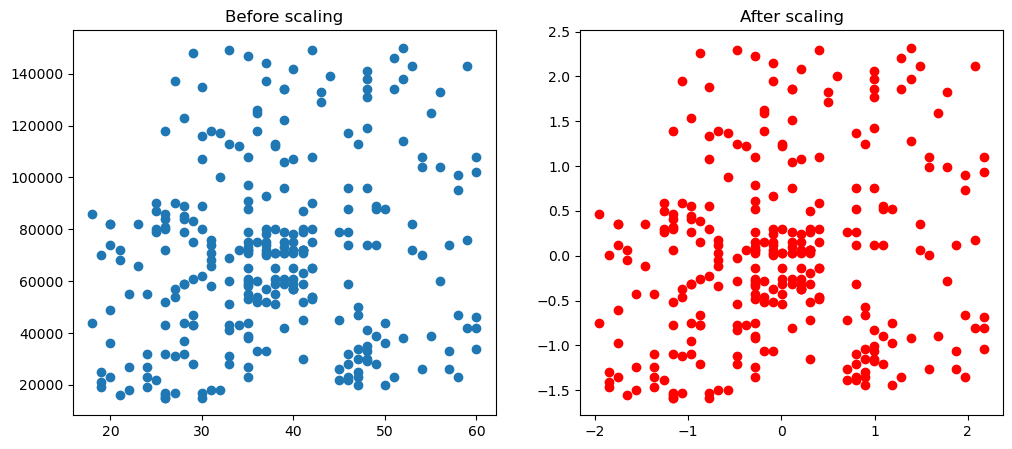

In [32]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title('Before scaling')
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color='r')
ax2.set_title('After scaling')

Text(0.5, 1.0, 'After_scaling')

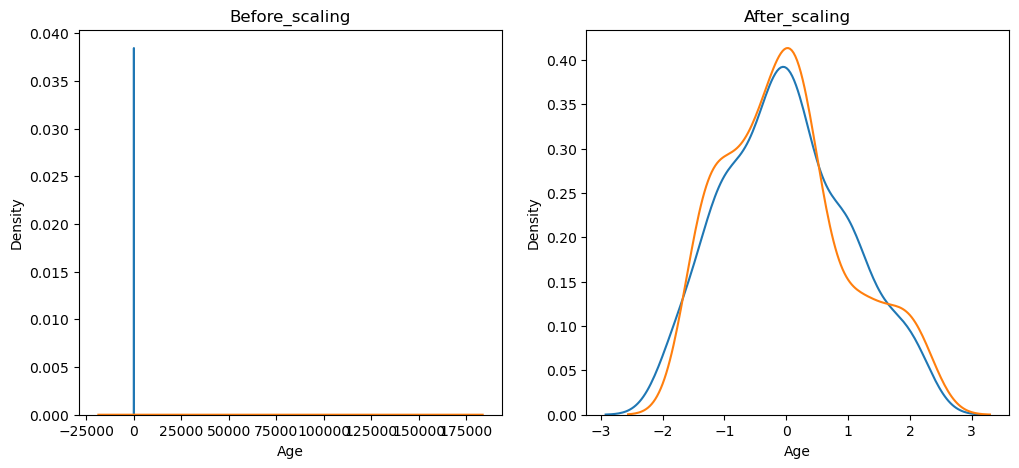

In [37]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)
ax1.set_title('Before_scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
ax2.set_title('After_scaling')


## Comparison of Distributions

Text(0.5, 1.0, 'Age Distribution After Scaling')

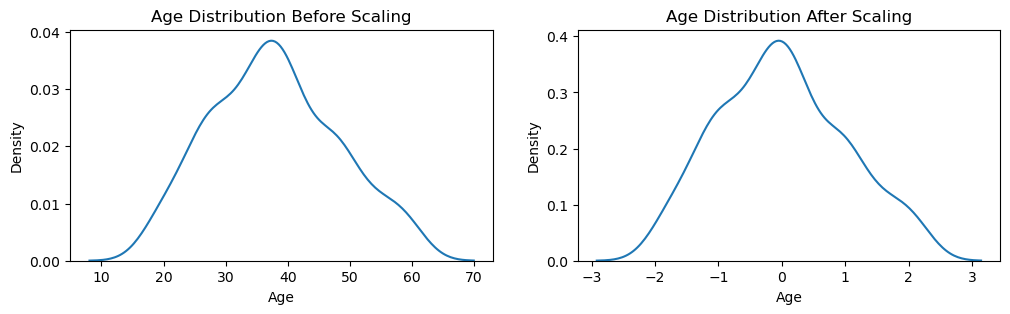

In [42]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,3))
sns.kdeplot(X_train['Age'],ax=ax1)
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
ax2.set_title('Age Distribution After Scaling')

## Why scaling is important?

In [49]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [50]:
lr.fit(X_train,Y_train)
lr_scaled.fit(X_train_scaled,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [55]:
y_pred=lr.predict(X_test)
y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [58]:
from sklearn.metrics import accuracy_score

print('Actual:',accuracy_score(Y_test,y_pred))
print('Scaled:',accuracy_score(Y_test,y_pred_scaled))

Actual: 0.875
Scaled: 0.8666666666666667
